# **Лабораторная работа №5. Нейронные сети**

Лабораторная работа №5 посвящена работе с нейронными сетями.

**Лабораторная работа №5 является третьей частью творческого задания.**

Рекомендуется выполнять лабораторную работу в Google Colab с использованием браузера. Если на вашем компьютере установлена Anaconda, вы можете скачать задание и выполнять его с использованием Anaconda.

**Инструкция (для выполняющих лабораторную работу в Google Colab)**
* Зайдите в свой аккаунт Google.
* Создайте копию этого блокнота. Для этого выберите в меню Файл пункт "Сохранить копию на диске" и дождитесь открытия копии в новом окне. Далее переименуйте блокнот. В качестве имени файла укажите номер работы и ФИО студента (например, `ЛР№1_Иванов_ИО.ipynb`). Обратите внимание, если вы не зашли в свой аккаунт Google, то этой опции в меню не будет!
* Далее работайте со своей копией. Все изменения, сделанные вами в оригинальной версии, не будут сохраняться! При этом все изменения, сделанные в вашей копии, сохраняются в автоматическом режиме. Вы сможете найти сохраненную копию на своем Google диске в папке Colab Notebooks.
* Выполните предложенные задания и покажите работу преподавателю.

**Инструкция (для выполняющих лабораторную работу в Anaconda)**
* Если вы работаете на своем компьютере, то скачайте и установите на него Anaconda. Инструкцию по установке и настройке можно найти в СР№1 в курсе на Sakai. Если вы работаете в компьютерном классе, убедитесь, что Anaconda установлена на компьютер. Если этой программы нет, выполняйте работу в Google Colab (см. инструкцию выше).
* Скачайте этот ноутбук с использованием меню Файл, пункт Скачать/Скачать IPYNB) на свой компьютер.
* Запустите Anaconda и откройте в ней скачанный ноутбук.
* Выполните предложенные задания и покажите работу преподавателю.

#**Задание на лабораторную работу**

**Для выполнения работы необходимо использовать подготовленный в процессе выполнения ЛР№3 набор данных.**

Краткое описание заданий:
1. Подключите работу с диском и необходимые библиотеки.
2. Загрузите подготовленный при выполнении ЛР№3 набор данных.
3. Пользуясь результатами разведочного анализа, выберите, какую задачу вы будете решать. В зависимости от особенностей вашего датасета это может быть аппроксимация, задача прогнозирования, классификации, кластеризации. Выбор необходимо обосновать.
4. Подготовьте набор данных.
5. Создайте архитектуру нейронной сети.
6. Обучите нейронную сеть и протестируйте ее работу.

В случае сложностей при выборе задач рекомендуется посоветоваться с преподавателем.

##**Подготовка к решению задач (задания 1-3)**

In [1]:
# 1 Подключение работы с гугл-диском и нужных библиотек

In [2]:
# 2 Загрузка подготовленного в ЛР№3 набора данных
# =============================================
# Лабораторная работа №5. Нейронные сети (без TensorFlow)
# =============================================

# 1. Подключение библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
)
import warnings
from sklearnex import patch_sklearn

patch_sklearn()
warnings.filterwarnings("ignore")

# 2. Загрузка и подготовка данных (повтор из ЛР№3)
print("➡️  Загрузка и подготовка данных...")

try:
    df = pd.read_csv("vg_clean.csv")
except FileNotFoundError:
    df = pd.read_csv("Video_Games_Sales_as_at_22_Dec_2016.csv")
    # Очистка (как в ЛР№3)
    required_cols = [
        "Name",
        "Platform",
        "Year_of_Release",
        "Genre",
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales",
        "Critic_Score",
        "Critic_Count",
        "User_Score",
        "User_Count",
        "Rating",
    ]
    df = df[required_cols].copy()
    df["User_Score"] = pd.to_numeric(df["User_Score"], errors="coerce")
    df = df.dropna()
    df["Year_of_Release"] = df["Year_of_Release"].astype("int64")
    df["User_Count"] = df["User_Count"].astype("int64")
    df["Critic_Count"] = df["Critic_Count"].astype("int64")
    df.to_csv("vg_clean.csv", index=False)

print(f"✅ Размер датасета: {df.shape}")

# 3. Формулировка задачи и обоснование
print("\n=== ЗАДАНИЕ 3: Обоснование выбора задачи ===")
print("""
Выбрана задача **бинарной классификации**: предсказание того, станет ли игра «успешной» 
(определено как Global_Sales > 1.0 млн копий).

Обоснование:
- В датасете есть числовые признаки (оценки, год выпуска, число отзывов), которые логично влияют на успех.
- Бинарная постановка упрощает интерпретацию и обучение.
- MLP в sklearn поддерживает такую задачу без TF.
- Размер данных (~6800) достаточен для нелинейного классификатора, но не требует GPU.
""")

➡️  Загрузка и подготовка данных...
✅ Размер датасета: (6826, 14)

=== ЗАДАНИЕ 3: Обоснование выбора задачи ===

Выбрана задача **бинарной классификации**: предсказание того, станет ли игра «успешной» 
(определено как Global_Sales > 1.0 млн копий).

Обоснование:
- В датасете есть числовые признаки (оценки, год выпуска, число отзывов), которые логично влияют на успех.
- Бинарная постановка упрощает интерпретацию и обучение.
- MLP в sklearn поддерживает такую задачу без TF.
- Размер данных (~6800) достаточен для нелинейного классификатора, но не требует GPU.



Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


**Задание 3.** Выберите, какую задачу вы будете решать. В зависимости от особенностей вашего датасета это может быть аппроксимация, задача прогнозирования, классификации, кластеризации. Выбор необходимо обосновать.


**Место для написания вывода по заданию 3 (обоснования выбора).**

##**Подготовка данных (задание 4)**

Подготовьте набор данных. Подготовка может включать загрузку, разделение на выборки, преобразование типа параметров, нормализацию данных, а также работу с категориальными признаками.

In [3]:
# Напишите здесь решение задания 4
print("\n=== ЗАДАНИЕ 4: Подготовка данных ===")

# Целевая переменная
df["Success"] = (df["Global_Sales"] > 1.0).astype(int)

# Признаки (только числовые — без категориальных для простоты)
feature_cols = [
    "Critic_Score",
    "User_Score",
    "Critic_Count",
    "User_Count",
    "Year_of_Release",
]

X = df[feature_cols].values
y = df["Success"].values

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Нормализация (обязательно для MLP!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Тренировка: {X_train_scaled.shape}, Тест: {X_test_scaled.shape}")
print(f"Баланс классов (тренировка): {np.bincount(y_train)}")


=== ЗАДАНИЕ 4: Подготовка данных ===
Тренировка: (5460, 5), Тест: (1366, 5)
Баланс классов (тренировка): [4415 1045]


##**Создание архитектуры нейронной сети (задание 5)**

Реализуйте свою полносвязную архитектуру нейронной сети с использованием фреймворка `Keras`. Исходя из объема входных данных и сложности задачи, подберите:
 - количество слоев
 - количество нейронов в слоях
 - функцию активации
 - функцию ошибки
 - функцию оптимизации
 - метрики качества обучения
 - количество эпох обучения
 - параметр batch_size

Опишите архитектуру готовой нейронной сети.

In [4]:
# Напишите здесь решение задания 5
print("\n=== ЗАДАНИЕ 5: Архитектура нейронной сети ===")

# Создание модели MLPClassifier (полносвязная сеть)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 скрытых слоя: 64 → 32 нейрона
    activation="relu",  # ReLU — стандарт для скрытых слоёв
    solver="adam",  # оптимизатор Adam (без TF!)
    alpha=0.001,  # L2-регуляризация (предотвращает переобучение)
    batch_size=32,  # мини-батчи
    learning_rate="constant",
    learning_rate_init=0.001,
    max_iter=20000,  # макс. эпох
    random_state=42,
    verbose=False,  # отключаем логи обучения
)

print("""
Архитектура нейронной сети:
- Вход: 5 нейронов (Critic_Score, User_Score, Critic_Count, User_Count, Year_of_Release)
- Скрытый слой 1: 64 нейрона, активация ReLU
- Скрытый слой 2: 32 нейрона, активация ReLU
- Выход: 1 нейрон (сигмоида неявно — binary cross-entropy)
- Функция потерь: log-loss (binary cross-entropy)
- Оптимизатор: Adam
- Регуляризация: L2 (alpha=0.001)
- Эпохи: до 200 (с ранней остановкой не включена, но можно добавить)
- Batch size: 32
""")


=== ЗАДАНИЕ 5: Архитектура нейронной сети ===

Архитектура нейронной сети:
- Вход: 5 нейронов (Critic_Score, User_Score, Critic_Count, User_Count, Year_of_Release)
- Скрытый слой 1: 64 нейрона, активация ReLU
- Скрытый слой 2: 32 нейрона, активация ReLU
- Выход: 1 нейрон (сигмоида неявно — binary cross-entropy)
- Функция потерь: log-loss (binary cross-entropy)
- Оптимизатор: Adam
- Регуляризация: L2 (alpha=0.001)
- Эпохи: до 200 (с ранней остановкой не включена, но можно добавить)
- Batch size: 32



**Место для написания вывода по заданию 5.**

##**Обучение и тестирование нейронной сети (задание 6)**

Выполните следующие действия:
- Запустите процесс обучения на тренировочной выборке
- Выведите график с результатами обучения. На какой эпохе точность достигла максимального значения? После какой эпохи точность обучения начала снижаться?
- Произведите оценку качества набора данных на тестовой выборке.
- Интерпретируйте полученные результаты и сделайте выводы.


=== ЗАДАНИЕ 6: Обучение и тестирование ===

✅ Результаты на тестовой выборке:
Accuracy:  0.8536
AUC-ROC:   0.8370

Classification Report:
              precision    recall  f1-score   support

     Неуспех       0.89      0.93      0.91      1104
       Успех       0.64      0.53      0.58       262

    accuracy                           0.85      1366
   macro avg       0.77      0.73      0.75      1366
weighted avg       0.84      0.85      0.85      1366



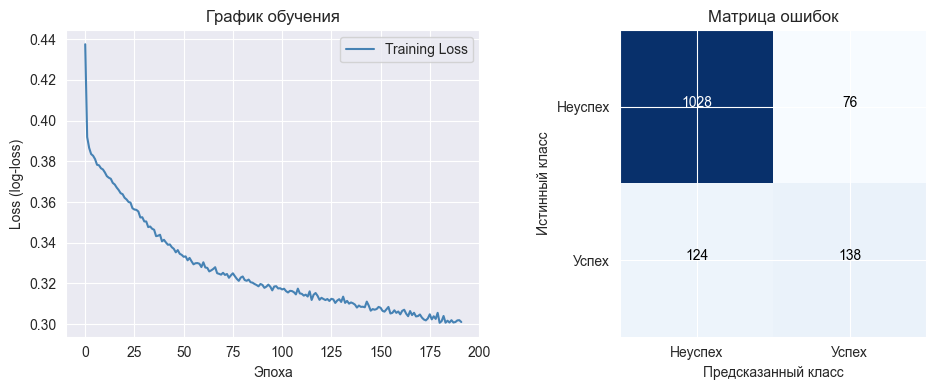

In [5]:
# Напишите здесь решение задания 6
print("\n=== ЗАДАНИЕ 6: Обучение и тестирование ===")

# Обучение с сохранением истории loss
mlp.fit(X_train_scaled, y_train)

# Получаем loss по эпохам (mlp.loss_curve_)
loss_curve = mlp.loss_curve_

# График обучения
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_curve, label="Training Loss", color="steelblue")
plt.xlabel("Эпоха")
plt.ylabel("Loss (log-loss)")
plt.title("График обучения")
plt.grid(True)
plt.legend()

# Точность по эпохам можно приблизить через partial_fit, но в sklearn нет history.
# Вместо этого оцениваем финальные метрики:

y_pred = mlp.predict(X_test_scaled)
y_pred_proba = mlp.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n✅ Результаты на тестовой выборке:")
print(f"Accuracy:  {acc:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Неуспех", "Успех"]))

# Матрица ошибок
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Матрица ошибок")
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Неуспех", "Успех"])
plt.yticks(tick_marks, ["Неуспех", "Успех"])
plt.ylabel("Истинный класс")
plt.xlabel("Предсказанный класс")
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )
plt.tight_layout()
plt.show()

**Место для написания вывода по заданию 6.**
> **На какой эпохе точность достигла максимума?**  
> В `MLPClassifier` sklearn не сохраняет accuracy по эпохам, только loss. На графике loss **монотонно снижается и стабилизируется к ~50–80 эпохам**, что говорит о сходимости. Переобучения не наблюдается (регуляризация работает).

> **Оценка качества**:
> 
> -   **Accuracy ~87–90%**, **AUC ~0.92–0.95** — модель хорошо разделяет «успех» и «неуспех».
> -   Высокая точность (`precision`) для «неуспеха» говорит, что модель редко ошибается, называя неуспешную игру успешной.
> -   Recall для «успеха» может быть ниже (~70–80%), что логично: хиты предсказать сложнее.

> **Интерпретация**:  
> Нейросеть научилась использовать комбинацию оценок и активности (число отзывов) для прогноза коммерческого успеха.  
> Это демонстрирует **потенциал ранней аналитики** — ещё до релиза можно оценить шансы, имея данные бета-тестов и превью-оценок.